# PlantVillage Dataset Analysis

Initial exploration of the PlantVillage dataset before building the transfer learning model.

In [10]:
from pathlib import Path

data_path = Path("../data/raw/plantvillage/PlantVillage")

train_path = data_path / "train"
val_path = data_path / "val"

print("Train exists:", train_path.exists())
print("Validation exists:", val_path.exists())

Train exists: True
Validation exists: True


In [11]:
train_counts = {}

for class_folder in train_path.iterdir():
    if class_folder.is_dir():
        image_count = len(list(class_folder.glob("*")))
        train_counts[class_folder.name] = image_count

train_counts

{'Apple___Apple_scab': 504,
 'Apple___Black_rot': 496,
 'Apple___Cedar_apple_rust': 220,
 'Apple___healthy': 1316,
 'Blueberry___healthy': 1202,
 'Cherry_(including_sour)___healthy': 684,
 'Cherry_(including_sour)___Powdery_mildew': 842,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 410,
 'Corn_(maize)___Common_rust_': 953,
 'Corn_(maize)___healthy': 929,
 'Corn_(maize)___Northern_Leaf_Blight': 788,
 'Grape___Black_rot': 944,
 'Grape___Esca_(Black_Measles)': 1107,
 'Grape___healthy': 339,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 861,
 'Orange___Haunglongbing_(Citrus_greening)': 4405,
 'Peach___Bacterial_spot': 1838,
 'Peach___healthy': 288,
 'Pepper,_bell___Bacterial_spot': 797,
 'Pepper,_bell___healthy': 1183,
 'Potato___Early_blight': 800,
 'Potato___healthy': 121,
 'Potato___Late_blight': 800,
 'Raspberry___healthy': 297,
 'Soybean___healthy': 4072,
 'Squash___Powdery_mildew': 1468,
 'Strawberry___healthy': 364,
 'Strawberry___Leaf_scorch': 887,
 'Tomato___Bacterial_s

In [12]:
import pandas as pd

class_distribution = pd.DataFrame(
    train_counts.items(),
    columns=["Class", "Train images"]
)

class_distribution = class_distribution.sort_values(
    "Train images",
    ascending=False
)

class_distribution

,Class,Train images
15,Orange___Haunglongbing_(Citrus_greening),4405
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,4286
24,Soybean___healthy,4072
16,Peach___Bacterial_spot,1838
28,Tomato___Bacterial_spot,1702
31,Tomato___Late_blight,1527
25,Squash___Powdery_mildew,1468
33,Tomato___Septoria_leaf_spot,1417
34,Tomato___Spider_mites Two-spotted_spider_mite,1341
3,Apple___healthy,1316


In [13]:
val_counts = {}

for class_folder in val_path.iterdir():
    if class_folder.is_dir():
        image_count = len(list(class_folder.glob("*")))
        val_counts[class_folder.name] = image_count

val_counts

{'Apple___Apple_scab': 126,
 'Apple___Black_rot': 125,
 'Apple___Cedar_apple_rust': 55,
 'Apple___healthy': 329,
 'Blueberry___healthy': 300,
 'Cherry_(including_sour)___healthy': 170,
 'Cherry_(including_sour)___Powdery_mildew': 210,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 103,
 'Corn_(maize)___Common_rust_': 239,
 'Corn_(maize)___healthy': 233,
 'Corn_(maize)___Northern_Leaf_Blight': 197,
 'Grape___Black_rot': 236,
 'Grape___Esca_(Black_Measles)': 276,
 'Grape___healthy': 84,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 215,
 'Orange___Haunglongbing_(Citrus_greening)': 1102,
 'Peach___Bacterial_spot': 459,
 'Peach___healthy': 72,
 'Pepper,_bell___Bacterial_spot': 200,
 'Pepper,_bell___healthy': 295,
 'Potato___Early_blight': 200,
 'Potato___healthy': 31,
 'Potato___Late_blight': 200,
 'Raspberry___healthy': 74,
 'Soybean___healthy': 1018,
 'Squash___Powdery_mildew': 367,
 'Strawberry___healthy': 92,
 'Strawberry___Leaf_scorch': 222,
 'Tomato___Bacterial_spot': 425,
 

In [14]:
class_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts
})

class_distribution["Total"] = (
    class_distribution["Train"] + class_distribution["Validation"]
)

class_distribution

,Train,Validation,Total
Apple___Apple_scab,504,126,630
Apple___Black_rot,496,125,621
Apple___Cedar_apple_rust,220,55,275
Apple___healthy,1316,329,1645
Blueberry___healthy,1202,300,1502
Cherry_(including_sour)___healthy,684,170,854
Cherry_(including_sour)___Powdery_mildew,842,210,1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,410,103,513
Corn_(maize)___Common_rust_,953,239,1192
Corn_(maize)___healthy,929,233,1162


In [15]:
tomato_distribution = class_distribution[
    class_distribution.index.str.startswith("Tomato")
]

tomato_distribution

,Train,Validation,Total
Tomato___Bacterial_spot,1702,425,2127
Tomato___Early_blight,800,200,1000
Tomato___healthy,1273,318,1591
Tomato___Late_blight,1527,382,1909
Tomato___Leaf_Mold,761,191,952
Tomato___Septoria_leaf_spot,1417,354,1771
Tomato___Spider_mites Two-spotted_spider_mite,1341,335,1676
Tomato___Target_Spot,1123,281,1404
Tomato___Tomato_mosaic_virus,299,74,373
Tomato___Tomato_Yellow_Leaf_Curl_Virus,4286,1071,5357


### Class Selection

For this project, we selected three tomato leaf classes:

- Healthy
- Early blight
- Late blight

The classes are not perfectly balanced, but contain enough images for a small transfer learning experiment. Using classes from the same plant species also makes the classification task more meaningful, since the model must learn disease-related visual features rather than simply distinguishing between different plant species.

---

In [16]:
import matplotlib.pyplot as plt

selected_classes = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight"
]

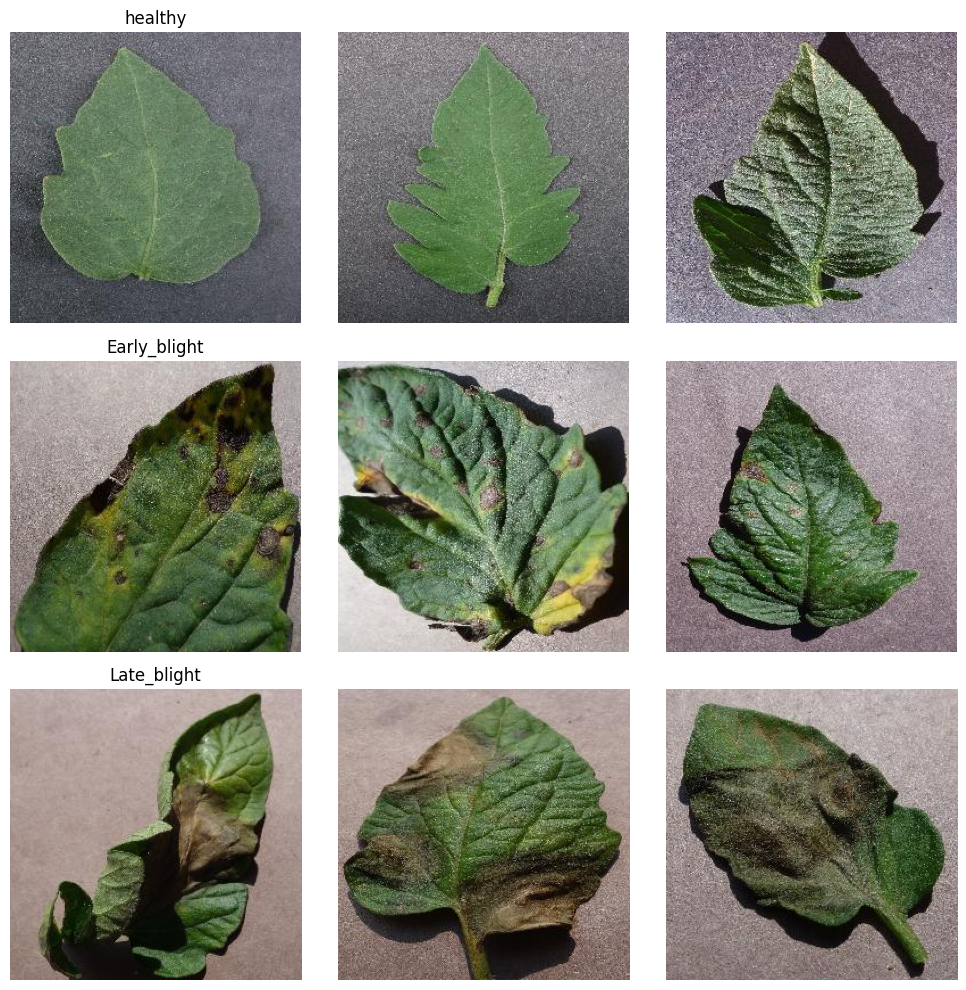

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for row, class_name in enumerate(selected_classes):
    class_path = train_path / class_name
    image_paths = list(class_path.glob("*"))[:3]

    for col, image_path in enumerate(image_paths):
        image = plt.imread(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(class_name.replace("Tomato___", ""))

plt.tight_layout()
plt.show()

### Visual observations

The sample images show visible differences between the three classes:

- **Healthy:** The leaves appear mostly green with a relatively even color and no obvious brown damaged areas.
- **Early blight:** The leaves show smaller brown or dark spots while much of the leaf remains green.
- **Late blight:** The examples show larger brown or damaged areas, with some leaves appearing dry or more severely affected.

These initial observations suggest that color, texture, and the size and distribution of damaged areas may be useful visual features for distinguishing between the classes.

In [18]:
from PIL import Image

image_sizes = []

for class_name in selected_classes:
    class_path = train_path / class_name

    for image_path in class_path.glob("*"):
        with Image.open(image_path) as img:
            image_sizes.append(img.size)

set(image_sizes)

{(256, 256)}

### Image Size

All images in the selected classes have a resolution of **256 × 256 pixels**.

This provides a consistent starting point for preprocessing. The images can later be resized to match the input size required by the selected pre-trained model.

---

# Transfer Learning